## Remember a Custom Random Image Dataset from S3

### Objective
Recover the manifest entry from S3, remember all stored images, and rebuild a dictionary that maps each image name to a `PIL.Image.Image` instance.


In [1]:
%load_ext autoreload
%autoreload 2

### Objective
Import the notebook dependencies, configure paths, and define the constants used by this example.


In [2]:
import numpy as np
from PIL import Image

import laila
from laila.pool import S3Pool

POOL_NICKNAME = "custom_image_s3_pool"
MANIFEST_NICKNAME = "my_dataset_manifest"


/home/ubuntu/laila/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Objective
Define helpers for building the S3 pool and loading the manifest entry from S3.


In [3]:
# These argument names are arbitrary and can be changed by the user.
# laila.args is just a container for user-provided arguments.
# Replace these placeholders with your own AWS credentials before running.
laila.args.AWS_BUCKET_NAME = "your-bucket-name"
laila.args.AWS_ACCESS_KEY_ID = "your-access-key-id"
laila.args.AWS_SECRET_ACCESS_KEY = "your-secret-access-key"
laila.args.AWS_REGION = "us-east-1"


def build_s3_pool() -> S3Pool:
    return S3Pool(
        bucket_name=laila.args.AWS_BUCKET_NAME,
        access_key_id=laila.args.AWS_ACCESS_KEY_ID,
        secret_access_key=laila.args.AWS_SECRET_ACCESS_KEY,
        region_name=laila.args.AWS_REGION,
    )


def load_manifest(pool_nickname: str) -> dict[str, str]:
    manifest_entry_id = laila.constant(
        data=np.zeros(1, dtype=np.uint8),
        nickname=MANIFEST_NICKNAME,
    ).global_id
    manifest_future = laila.remember(manifest_entry_id, pool_nickname=pool_nickname)
    print("Manifest future type:", type(manifest_future).__name__)
    manifest_future.wait()
    return dict(manifest_future.result.data)


### Objective
Register the S3 pool, recover the manifest from its deterministic nickname, and inspect a few manifest rows.


In [4]:
s3_pool = build_s3_pool()
laila.add_pool(s3_pool, pool_nickname=POOL_NICKNAME)

manifest = load_manifest(pool_nickname=POOL_NICKNAME)

print("Manifest size:", len(manifest))
print("First item:", next(iter(manifest.items())))

Manifest future type: ConcurrentPackageFuture
Manifest size: 100
First item: ('image_0', 'LAILA:ENTRY:GLOBAL_ID:b0f18c7b-bb24-561d-a287-f1b20c35a2f5')


### Objective
Remember all image entries listed in the manifest and rebuild an `image_name -> PIL Image` dictionary.


In [5]:
image_names = list(manifest.keys())
image_entry_ids = [manifest[name] for name in image_names]

remember_group_future = laila.remember(image_entry_ids, pool_nickname=POOL_NICKNAME)
print("Remember future type:", type(remember_group_future).__name__)
print("Status before wait:", remember_group_future.status)

remember_group_future.wait()
print("Status after wait:", remember_group_future.status)

recovered_entries = [child_future.result for child_future in remember_group_future]
images_by_name = {
    image_name: entry.data
    for image_name, entry in zip(image_names, recovered_entries)
}

print("Recovered images:", len(images_by_name))
print("First image key:", next(iter(images_by_name)))
print("First image type:", type(next(iter(images_by_name.values()))).__name__)

Remember future type: GroupFuture
Status before wait: {'total': 100.0, 'percentages': {'finished': 0.0, 'running': 0.0, 'not_started': 100.0, 'error': 0.0, 'cancelled': 0.0}}
Status after wait: {'total': 100.0, 'percentages': {'finished': 100.0, 'running': 0.0, 'not_started': 0.0, 'error': 0.0, 'cancelled': 0.0}}
Recovered images: 100
First image key: image_0
First image type: Image


### Objective
Inspect one recovered image and verify that the dictionary values are usable PIL objects.


Sample image name: image_0
Sample image mode: RGB
Sample image size: (64, 64)


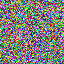

In [6]:
sample_name = image_names[0]
sample_image = images_by_name[sample_name]

print("Sample image name:", sample_name)
print("Sample image mode:", sample_image.mode)
print("Sample image size:", sample_image.size)
sample_image